## Problem Statement:
Detect human faces in still images using the SSD configured with the Caffe pretrained model.

In [ ]:
# create a directory names model and enter that directory
%mkdir model/
%cd model

# load the pre-trained model and weights
!wget https://raw.githubusercontent.com/georgiosouzounis/face-detection-ssd-caffe/main/model/deploy.prototxt.txt

!wget https://github.com/georgiosouzounis/face-detection-ssd-caffe/raw/main/model/res10_300x300_ssd_iter_140000.caffemodel

# move out of the directory once the model is loaded
%cd ../

/content/model
--2025-01-12 04:51:28--  https://raw.githubusercontent.com/georgiosouzounis/face-detection-ssd-caffe/main/model/deploy.prototxt.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28092 (27K) [text/plain]
Saving to: ‘deploy.prototxt.txt’

deploy.prototxt.txt 100%[===================>]  27.43K  --.-KB/s    in 0.002s  

2025-01-12 04:51:28 (16.7 MB/s) - ‘deploy.prototxt.txt’ saved [28092/28092]

--2025-01-12 04:51:28--  https://github.com/georgiosouzounis/face-detection-ssd-caffe/raw/main/model/res10_300x300_ssd_iter_140000.caffemodel
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/

In [ ]:
# import libraries
import numpy as np
import cv2

In [ ]:
# load the serialized model from the local copy in model/
model_cfg = '/content/model/deploy.prototxt.txt'
model_weights = '/content/model/res10_300x300_ssd_iter_140000.caffemodel'

In [ ]:
# read the model
detector = cv2.dnn.readNetFromCaffe(model_cfg, model_weights)

In [ ]:
# read the test image
image = cv2.imread('/content/macron.jpg')
(h, w) = image.shape[:2]

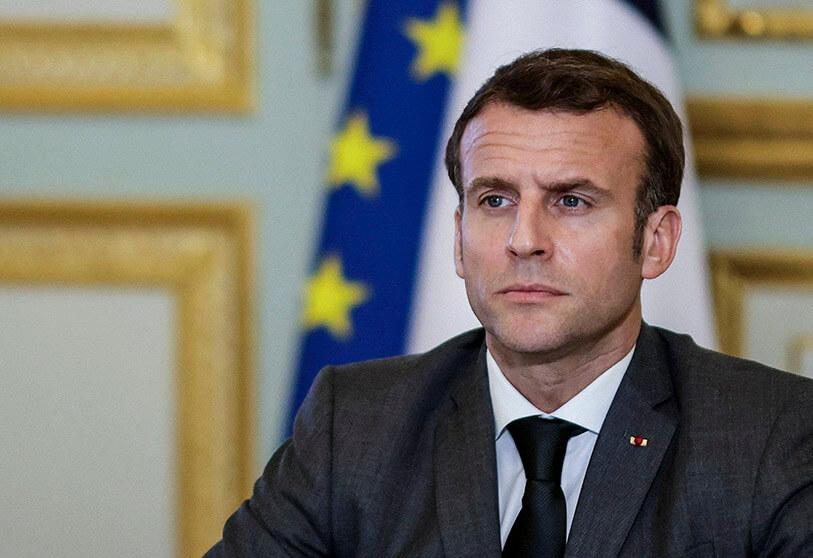

In [ ]:
# display the image
from google.colab.patches import cv2_imshow
cv2_imshow(image)

In [ ]:
# set the intensity scaling factor; 1 in this case, i.e. original image intensities
scale_factor = 1.0

# set the new dimensions for image resizing to match the network requirements
new_size = (300, 300)

In [ ]:
# create a blob using OpenCV's DNN functionality and by performing mean subtraction
# to normalize the input
blob = cv2.dnn.blobFromImage(image, scale_factor, new_size, (127.5, 127.5, 127.5), swapRB=True, crop=False)

In [ ]:
# set the blob as input to the network
detector.setInput(blob)

In [ ]:
# compute the forward pass
detections = detector.forward()
detections.shape

(1, 1, 200, 7)

In [ ]:
# analyse detections
detections[0][0][0]

array([0.        , 1.        , 0.9996408 , 0.5665413 , 0.18484493,
       0.7850617 , 0.6287232 ], dtype=float32)

In [ ]:
# analyse the detections
confidence_threshold = 0.5

for i in range(0, detections.shape[2]):
  confidence = detections[0, 0, i, 2]
  if confidence > confidence_threshold:
    box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
    (startX, startY, endX, endY) = box.astype('int')
    cv2.rectangle(image, (startX, startY), (endX, endY), (0, 0, 255), 2)
    text = "confidence: {:.2f}%".format(confidence * 100)
    y = startY - 10 if startY - 10 > 10 else startY + 10
    cv2.putText(image, text, (startX, y), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)

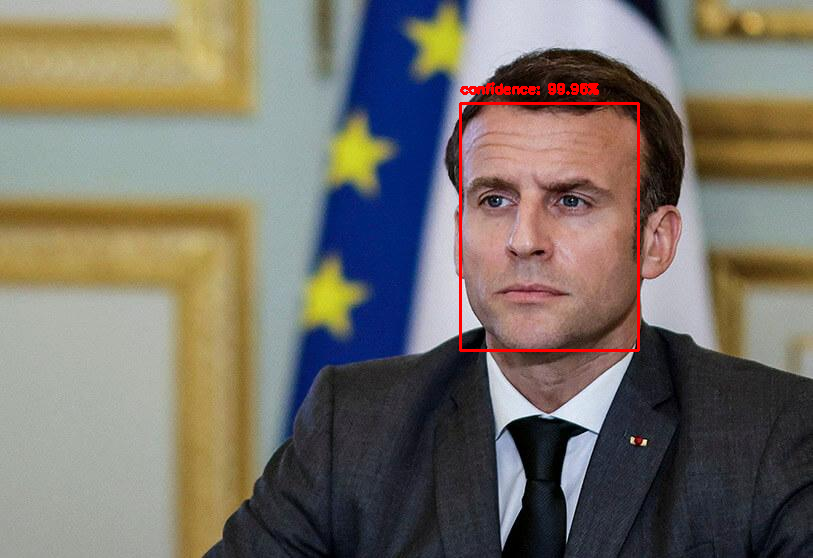

In [ ]:
# print the image
cv2_imshow(image)